In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

ONSET_PATH  = "processed/floodsense_onset.csv"
ONSET_PREDS = "onset_models/oof_preds_onset.npy"
CONT_PREDS  = "engineered_models/oof_preds_engineered.npy"
PLOTS_DIR   = "backtest_plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

def section(title):
    print("\n" + "=" * 75 + f"\n{title}\n" + "=" * 75)

In [5]:
df = pd.read_csv(ONSET_PATH)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["district", "date"]).reset_index(drop=True)

df["onset_pred"]        = np.load(ONSET_PREDS)
df["continuation_pred"] = np.load(CONT_PREDS)
print(f"Loaded {len(df)} rows with both models' predictions")
df.head()

Loaded 1365 rows with both models' predictions


,date,evaporation,precipitation,pressure,soil_moisture,temperature,wind_speed,humidity,month,is_monsoon,...,water_area_km2_lag7_zscore,water_area_km2_lag14_zscore,days_since_heavy_rain,days_since_dry_day,days_in_monsoon,precip_x_soil_moisture,precip_7day_x_monsoon,pressure_low_x_humidity_high,onset_pred,continuation_pred
0,2023-01-01,-0.000230,0.000135,100639.5491,0.087776,16.712126,0.625041,50.787158,1,0,...,NaN,NaN,NaN,0.0,0,0.000012,0.0,0.0,0.146962,0.761984
1,2023-01-01,-0.000230,NaN,100639.5491,0.087776,16.712126,0.625041,50.787158,1,0,...,NaN,NaN,NaN,0.0,0,NaN,0.0,0.0,0.130073,0.555538
2,2023-01-02,-0.000215,0.000000,100800.0680,0.087691,16.070381,2.556115,54.975463,1,0,...,NaN,NaN,NaN,0.0,0,0.000000,0.0,0.0,0.440289,0.214760
3,2023-01-03,-0.000217,0.000000,101029.1779,0.087694,15.405261,2.904837,49.248183,1,0,...,NaN,NaN,NaN,0.0,0,0.000000,0.0,0.0,0.142817,0.013371
4,2023-01-04,-0.000214,0.000000,101026.6490,0.087631,14.635752,2.287333,51.012060,1,0,...,NaN,NaN,NaN,0.0,0,0.000000,0.0,0.0,0.195425,0.021542


In [6]:
section("STEP 1 — Identify distinct flood events")

df["event_num"] = df.groupby("district")["flood_onset"].cumsum()
df.loc[df["flood_event"] == 0, "event_num"] = np.nan
df["event_id"] = df["district"] + "_E" + df["event_num"].astype("Int64").astype(str)

event_durations = (df.dropna(subset=["event_num"])
                     .groupby("event_id")
                     .agg(district=("district", "first"),
                          start=("date", "min"),
                          end=("date", "max"),
                          rows_in_event=("flood_event", "size"))
                     .reset_index())
event_durations["calendar_span_days"] = (event_durations["end"] - event_durations["start"]).dt.days + 1
event_durations = event_durations.sort_values("rows_in_event", ascending=False)

print(f"\nTotal distinct flood events: {len(event_durations)}")
print(f"\nLongest events:")
print(event_durations.head(10).to_string(index=False))


STEP 1 — Identify distinct flood events

Total distinct flood events: 135

Longest events:
          event_id       district      start        end  rows_in_event  calendar_span_days
Sindh_District_E30 Sindh_District 2022-09-08 2022-09-13              8                   6
Sindh_District_E28 Sindh_District 2022-08-27 2022-09-01              8                   6
   KP_District_E21    KP_District 2024-06-29 2024-07-03              7                   5
   KP_District_E22    KP_District 2024-07-11 2024-07-15              7                   5
   KP_District_E26    KP_District 2024-08-16 2024-08-20              7                   5
Sindh_District_E32 Sindh_District 2022-09-20 2022-09-24              7                   5
   KP_District_E20    KP_District 2024-06-17 2024-06-21              7                   5
Sindh_District_E22 Sindh_District 2022-06-28 2022-07-02              7                   5
Sindh_District_E20 Sindh_District 2022-06-04 2022-06-08              7                   

In [7]:
section("STEP 2 — Extract pre-onset predictions for every event")

onset_rows = df[df["flood_onset"] == 1].copy()
print(f"Total onset events: {len(onset_rows)}")

records = []
for _, onset_row in onset_rows.iterrows():
    district   = onset_row["district"]
    onset_date = onset_row["date"]
    event_id   = onset_row["event_id"]

    records.append({
        "event_id": event_id, "district": district,
        "days_before_onset": 0,
        "onset_pred": onset_row["onset_pred"],
        "continuation_pred": onset_row["continuation_pred"],
    })

    for d in range(1, 8):
        target_date = onset_date - pd.Timedelta(days=d)
        matching = df[(df["district"] == district) & (df["date"] == target_date)]
        if len(matching) > 0:
            records.append({
                "event_id": event_id, "district": district,
                "days_before_onset": d,
                "onset_pred": matching["onset_pred"].max(),
                "continuation_pred": matching["continuation_pred"].max(),
            })

records_df = pd.DataFrame(records)
print(f"Built records table: {records_df.shape}")
records_df.head()


STEP 2 — Extract pre-onset predictions for every event
Total onset events: 134
Built records table: (1052, 5)


,event_id,district,days_before_onset,onset_pred,continuation_pred
0,Balochistan_District_E1,Balochistan_District,0,0.305595,0.659885
1,Balochistan_District_E1,Balochistan_District,1,0.047556,0.025072
2,Balochistan_District_E1,Balochistan_District,2,0.195425,0.021542
3,Balochistan_District_E1,Balochistan_District,3,0.142817,0.013371
4,Balochistan_District_E1,Balochistan_District,4,0.440289,0.214760


In [8]:
section("STEP 3 — Lead-time statistics across all events")

print(f"{'Window':>20s}  {'n events':>9s}  "
      f"{'Onset model':>20s}  {'Continuation model':>20s}")
print(f"{' ':>20s}  {'with data':>9s}  "
      f"{'P>0.3   P>0.5':>20s}  {'P>0.3   P>0.5':>20s}")

sd = records_df[records_df["days_before_onset"] == 0]
sd_03_o = (sd["onset_pred"] >= 0.3).sum()
sd_05_o = (sd["onset_pred"] >= 0.5).sum()
sd_03_c = (sd["continuation_pred"] >= 0.3).sum()
sd_05_c = (sd["continuation_pred"] >= 0.5).sum()
n = len(sd)
print(f"  {'On onset day (d=0)':>18s}    {n:>5d}    "
      f"{sd_03_o:>4d} ({100*sd_03_o/n:.0f}%)  {sd_05_o:>3d} ({100*sd_05_o/n:.0f}%)   "
      f"{sd_03_c:>4d} ({100*sd_03_c/n:.0f}%)  {sd_05_c:>3d} ({100*sd_05_c/n:.0f}%)")

for max_days in [1, 2, 3, 5, 7]:
    sub = records_df[(records_df["days_before_onset"] >= 1) &
                      (records_df["days_before_onset"] <= max_days)]
    if len(sub) == 0:
        continue
    max_per_event = sub.groupby("event_id").agg(
        onset_max=("onset_pred", "max"),
        cont_max=("continuation_pred", "max"),
    )
    n_events = len(max_per_event)
    o_03 = (max_per_event["onset_max"] >= 0.3).sum()
    o_05 = (max_per_event["onset_max"] >= 0.5).sum()
    c_03 = (max_per_event["cont_max"]  >= 0.3).sum()
    c_05 = (max_per_event["cont_max"]  >= 0.5).sum()
    label = f"Days -1 to -{max_days} before"
    print(f"  {label:>18s}    {n_events:>5d}    "
          f"{o_03:>4d} ({100*o_03/n_events:.0f}%)  {o_05:>3d} ({100*o_05/n_events:.0f}%)   "
          f"{c_03:>4d} ({100*c_03/n_events:.0f}%)  {c_05:>3d} ({100*c_05/n_events:.0f}%)")


STEP 3 — Lead-time statistics across all events
              Window   n events           Onset model    Continuation model
                      with data         P>0.3   P>0.5         P>0.3   P>0.5
  On onset day (d=0)      134     119 (89%)  105 (78%)    116 (87%)  110 (82%)
  Days -1 to -1 before      134      23 (17%)   16 (12%)     36 (27%)   31 (23%)
  Days -1 to -2 before      134      27 (20%)   20 (15%)     38 (28%)   33 (25%)
  Days -1 to -3 before      134      35 (26%)   28 (21%)     41 (31%)   35 (26%)
  Days -1 to -5 before      134      37 (28%)   29 (22%)     52 (39%)   37 (28%)
  Days -1 to -7 before      134      42 (31%)   33 (25%)     63 (47%)   42 (31%)


In [9]:
section("STEP 4 — Mean predicted probability by days-before-onset")

curve = (records_df.groupby("days_before_onset")
                    .agg(n=("event_id", "size"),
                         mean_onset=("onset_pred", "mean"),
                         mean_cont=("continuation_pred", "mean"))
                    .reset_index()
                    .sort_values("days_before_onset"))

print(curve.to_string(index=False))


STEP 4 — Mean predicted probability by days-before-onset
 days_before_onset   n  mean_onset  mean_cont
                 0 134    0.639068   0.670096
                 1 134    0.128233   0.238937
                 2 132    0.062734   0.134178
                 3 131    0.097244   0.136211
                 4 131    0.034515   0.110576
                 5 131    0.042471   0.101546
                 6 130    0.049643   0.108080
                 7 129    0.065142   0.152704


In [10]:
section("STEP 5 — Case studies (longest event per district)")

case_studies = (event_durations.sort_values("rows_in_event", ascending=False)
                                 .groupby("district").head(1)
                                 .sort_values("rows_in_event", ascending=False))

print(case_studies.to_string(index=False))


STEP 5 — Case studies (longest event per district)
                event_id             district      start        end  rows_in_event  calendar_span_days
      Sindh_District_E30       Sindh_District 2022-09-08 2022-09-13              8                   6
         KP_District_E21          KP_District 2024-06-29 2024-07-03              7                   5
Balochistan_District_E19 Balochistan_District 2023-05-06 2023-05-09              6                   4


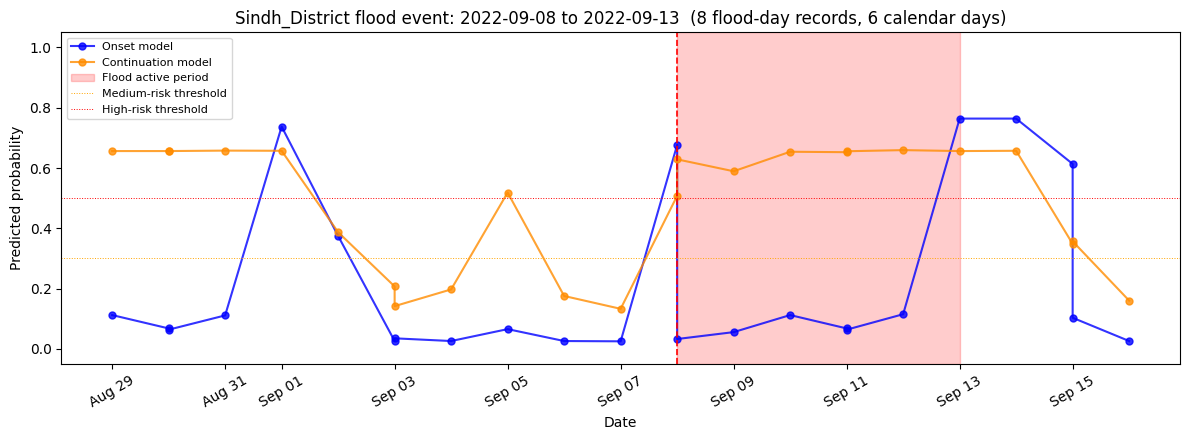

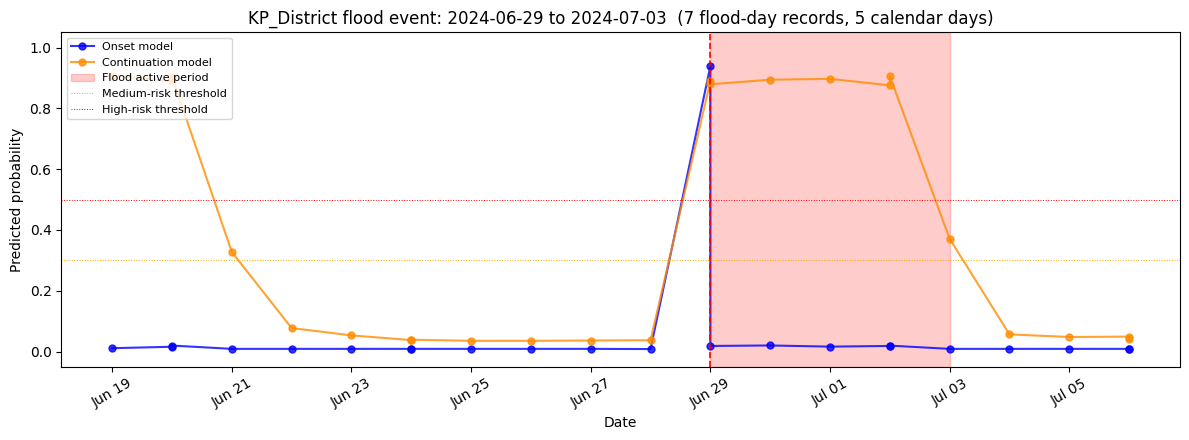

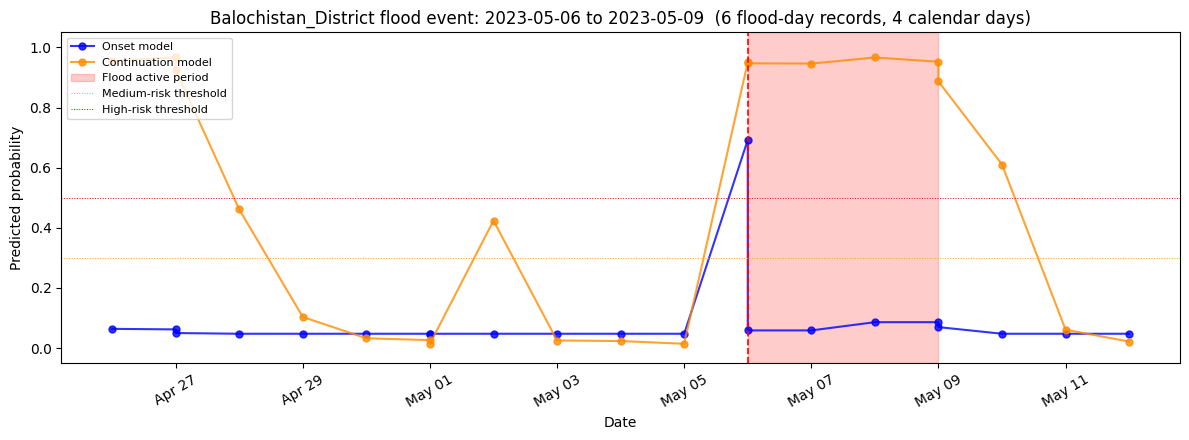

In [11]:
for _, ev in case_studies.iterrows():
    district = ev["district"]
    e_start, e_end = ev["start"], ev["end"]

    plot_start = e_start - pd.Timedelta(days=10)
    plot_end   = e_end + pd.Timedelta(days=3)
    plot_data  = df[(df["district"] == district) &
                    (df["date"] >= plot_start) &
                    (df["date"] <= plot_end)].sort_values("date")

    fig, ax = plt.subplots(figsize=(12, 4.5))
    ax.plot(plot_data["date"], plot_data["onset_pred"], "b-o",
            label="Onset model", alpha=0.8, markersize=5)
    ax.plot(plot_data["date"], plot_data["continuation_pred"], color="darkorange",
            marker="o", linestyle="-", label="Continuation model", alpha=0.8, markersize=5)
    ax.axvspan(e_start, e_end, alpha=0.2, color="red", label="Flood active period")
    ax.axvline(e_start, color="red", linestyle="--", linewidth=1.2)
    ax.axhline(0.3, color="orange", linestyle=":", linewidth=0.7, label="Medium-risk threshold")
    ax.axhline(0.5, color="red", linestyle=":", linewidth=0.7, label="High-risk threshold")
    ax.set_xlabel("Date")
    ax.set_ylabel("Predicted probability")
    ax.set_title(f"{district} flood event: {e_start.date()} to {e_end.date()}  "
                 f"({ev['rows_in_event']} flood-day records, {ev['calendar_span_days']} calendar days)")
    ax.legend(loc="upper left", fontsize=8)
    ax.set_ylim(-0.05, 1.05)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    plt.xticks(rotation=30)
    plt.tight_layout()
    safe_name = f"{district}_{e_start.strftime('%Y%m%d')}".replace("_District", "")
    plt.savefig(f"{PLOTS_DIR}/case_{safe_name}.png", dpi=80)
    plt.show()
    plt.close()

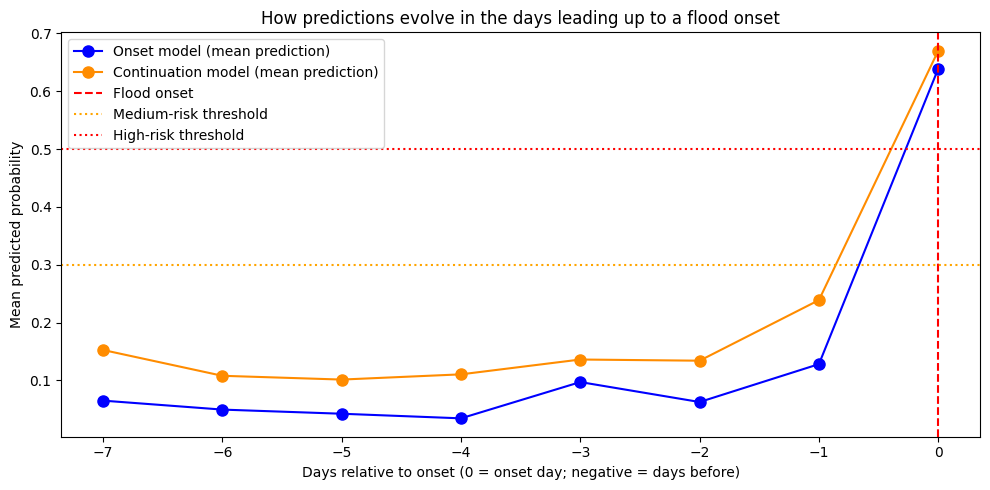

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(-curve["days_before_onset"], curve["mean_onset"],
        "b-o", label="Onset model (mean prediction)", markersize=8)
ax.plot(-curve["days_before_onset"], curve["mean_cont"],
        color="darkorange", marker="o", label="Continuation model (mean prediction)", markersize=8)
ax.axvline(0, color="red", linestyle="--", label="Flood onset")
ax.axhline(0.3, color="orange", linestyle=":", label="Medium-risk threshold")
ax.axhline(0.5, color="red",    linestyle=":", label="High-risk threshold")
ax.set_xlabel("Days relative to onset (0 = onset day; negative = days before)")
ax.set_ylabel("Mean predicted probability")
ax.set_title("How predictions evolve in the days leading up to a flood onset")
ax.legend()
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/pre_onset_curve.png", dpi=80)
plt.show()
plt.close()

In [13]:
section("PITCH-READY SUMMARY")

same_day = records_df[records_df["days_before_onset"] == 0]
sd_03 = (same_day["onset_pred"] >= 0.3).mean() * 100
sd_05 = (same_day["onset_pred"] >= 0.5).mean() * 100

window_3 = records_df[(records_df["days_before_onset"] >= 1) &
                       (records_df["days_before_onset"] <= 3)]
if len(window_3) > 0:
    max_in_window = window_3.groupby("event_id")["onset_pred"].max()
    n_events_w = len(max_in_window)
    pct_warned_3day = (max_in_window >= 0.3).mean() * 100
else:
    pct_warned_3day = 0
    n_events_w = 0

print(f"""
SAME-DAY DETECTION:
    Medium-risk alert (P ≥ 0.3):  {sd_03:.0f}% of events ({(same_day['onset_pred'] >= 0.3).sum()}/{len(same_day)})
    High-risk alert  (P ≥ 0.5):   {sd_05:.0f}% of events ({(same_day['onset_pred'] >= 0.5).sum()}/{len(same_day)})

ADVANCE WARNING (within 1-3 days before onset):
    Medium-risk fired in {pct_warned_3day:.0f}% of events that had data in the prior 3 days ({n_events_w} events covered)

Plots saved to {PLOTS_DIR}/
""")


PITCH-READY SUMMARY

SAME-DAY DETECTION:
    Medium-risk alert (P ≥ 0.3):  89% of events (119/134)
    High-risk alert  (P ≥ 0.5):   78% of events (105/134)

ADVANCE WARNING (within 1-3 days before onset):
    Medium-risk fired in 26% of events that had data in the prior 3 days (134 events covered)

Plots saved to backtest_plots/

